In [1]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

from src.config import SEED, DATA_PROC, OUTPUTS, CLASES
from src.mlp import train_mlp

random.seed(SEED)

/opt/miniconda3/envs/pf_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MLP para clasificación Real vs. generada por IA
## Fase 2 — Análisis PCA + Entrenamiento MLP

El MLP no puede trabajar directamente sobre los píxeles crudos: una imagen de 128×128×3 tiene **49152 features**, lo que hace el entrenamiento muy lento y propenso a overfitting.

Para reducir esa dimensionalidad usamos **PCA** (Análisis de Componentes Principales), que proyecta cada imagen a un espacio de muchas menos dimensiones conservando el 90% de la varianza.

Pipeline:
1. Calcular PCA sobre una muestra de 5000 imágenes de train
2. Guardar el objeto PCA para usarlo en entrenamiento y evaluación
3. Visualizar la reconstrucción para verificar que el 90% captura suficiente información
4. Entrenar el MLP sobre las representaciones comprimidas

## 1. Análisis de componentes PCA

Ajustamos PCA sobre una **muestra aleatoria de 5000 imágenes** de train (no el dataset completo) porque el SVD exacto sobre 48000 imágenes de 49152 features tardaría horas.

`whiten=True` normaliza cada componente a varianza unitaria para que el MLP entrene correctamente (sin esto, el primer componente tiene escala casi 10000 veces mayor que los últimos y el gradiente explota).

Matriz de entrada: (5000, 49152)  (0.25 GB)
Componentes para 90% de varianza: 352


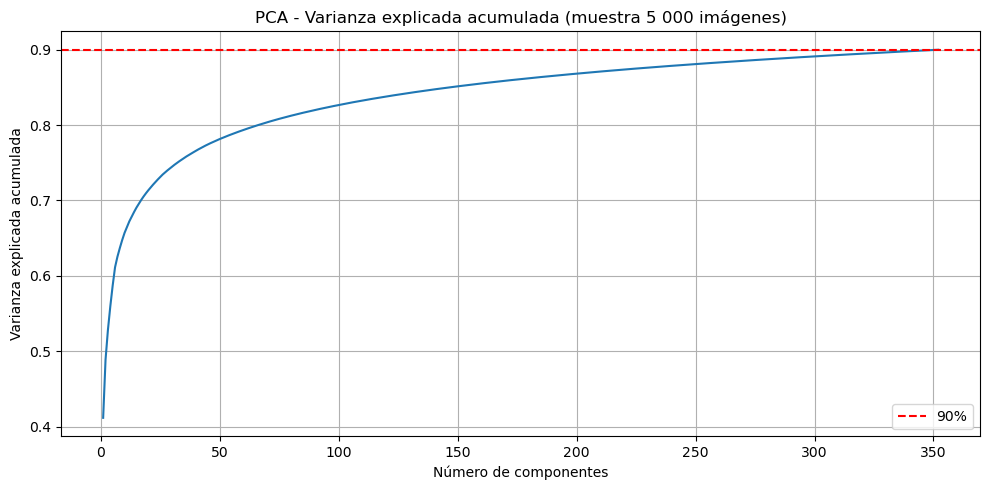

In [2]:
todos_los_paths = [
    p
    for label in CLASES
    for p in sorted((DATA_PROC / "train" / label).iterdir())
]
muestra = random.sample(todos_los_paths, 5000)

filas = []
for p in muestra:
    with Image.open(p) as img:
        filas.append(np.array(img, dtype=np.uint8).flatten())
X = np.stack(filas)
print(f"Matriz de entrada: {X.shape}  ({X.nbytes / 1e9:.2f} GB)")

pca = PCA(n_components=0.90, svd_solver="full", whiten=True, random_state=SEED)
pca.fit(X)
n_comp = pca.n_components_
print(f"Componentes para 90% de varianza: {n_comp}")

varianza_acum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_comp + 1), varianza_acum)
plt.axhline(0.90, color="r", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada (muestra 5 000 imágenes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Guardar el objeto PCA

Guardamos el objeto PCA ajustado con `joblib` para reutilizarlo en entrenamiento y evaluación sin tener que recalcularlo.

In [3]:
OUTPUTS.mkdir(exist_ok=True)
joblib.dump(pca, OUTPUTS / "pca_mlp.joblib")
print(f"PCA guardado en {OUTPUTS / 'pca_mlp.joblib'}")

PCA guardado en /Users/lautarocaminoa/Documents/UdeSA/Materias/ML/ProyectoFinal/PF_ML_Krinisky_Caminoa/outputs/pca_mlp.joblib


## 3. Reconstrucción visual

Verificamos que comprimir a casi 350 componentes no destruye demasiada información visual. Si la reconstrucción es reconocible, el MLP tiene suficiente señal para clasificar.

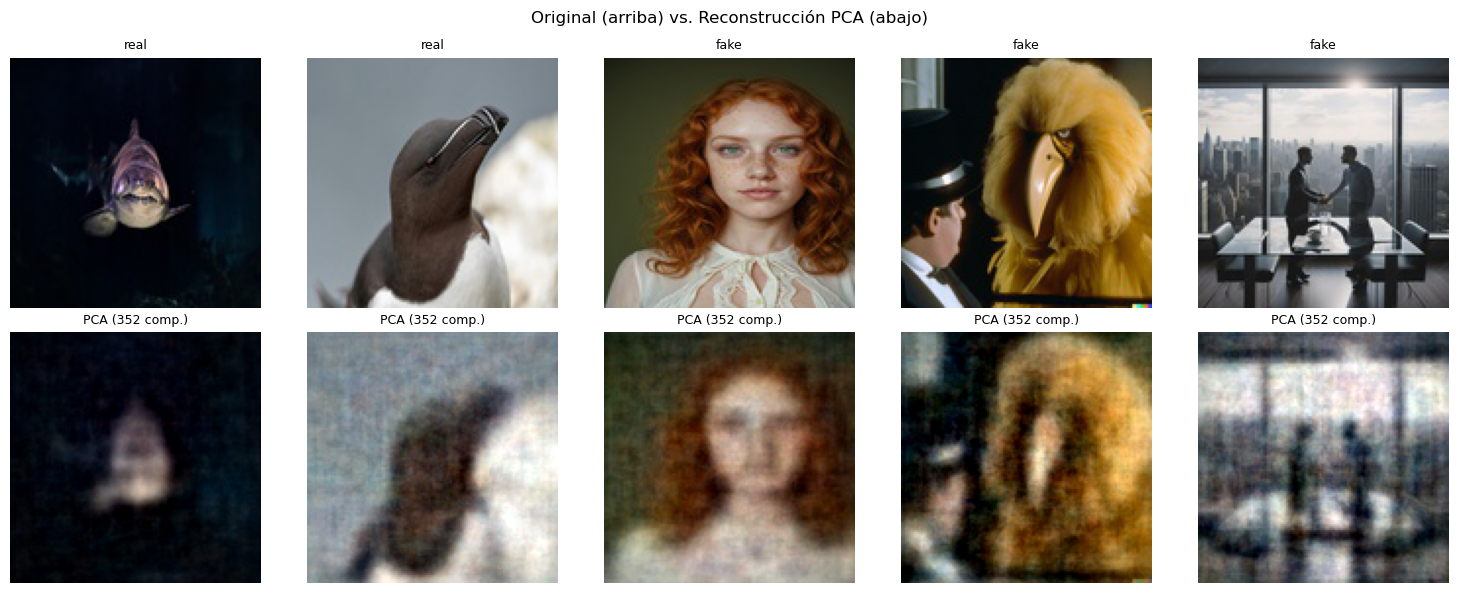

In [4]:
n_mostrar = 5
indices = random.sample(range(len(muestra)), n_mostrar)

fig, axes = plt.subplots(2, n_mostrar, figsize=(3 * n_mostrar, 6))

for col, idx in enumerate(indices):
    p = muestra[idx]
    label = p.parent.name  # "real" o "fake" — está en el nombre de la carpeta padre

    img_flat = filas[idx].reshape(1, -1)
    img_orig = filas[idx].reshape(128, 128, 3)
    img_rec  = pca.inverse_transform(pca.transform(img_flat)).reshape(128, 128, 3)
    img_rec  = np.clip(img_rec, 0, 255).astype(np.uint8)

    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(label, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_rec)
    axes[1, col].set_title(f"PCA ({n_comp} comp.)", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Original (arriba) vs. Reconstrucción PCA (abajo)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Entrenamiento del MLP

Entrenamos el MLP sobre las representaciones PCA de todas las imágenes de train y val. El entrenamiento usa early stopping: si `val_loss` no mejora en `PATIENCE` epochs consecutivos, se detiene y se carga el mejor checkpoint.

Dispositivo: mps


Train: torch.Size([47991, 352]) | Val: torch.Size([6000, 352])
Epoch   1/50  train_loss=0.6239  val_loss=0.5789  val_acc=0.6947
Epoch   2/50  train_loss=0.5589  val_loss=0.5589  val_acc=0.7117
Epoch   3/50  train_loss=0.5197  val_loss=0.5536  val_acc=0.7182
Epoch   4/50  train_loss=0.4895  val_loss=0.5583  val_acc=0.7113
Epoch   5/50  train_loss=0.4617  val_loss=0.5552  val_acc=0.7123
Epoch   6/50  train_loss=0.4361  val_loss=0.5668  val_acc=0.7105
Epoch   7/50  train_loss=0.4110  val_loss=0.5749  val_acc=0.7110
Epoch   8/50  train_loss=0.3954  val_loss=0.5853  val_acc=0.7105
Epoch   9/50  train_loss=0.3771  val_loss=0.5809  val_acc=0.7147
Epoch  10/50  train_loss=0.3569  val_loss=0.6132  val_acc=0.7147
Epoch  11/50  train_loss=0.3431  val_loss=0.6085  val_acc=0.7058
Epoch  12/50  train_loss=0.3327  val_loss=0.6031  val_acc=0.7082
Epoch  13/50  train_loss=0.3172  val_loss=0.6359  val_acc=0.7082
Early stopping en epoch 13.

Mejor val_loss: 0.5536


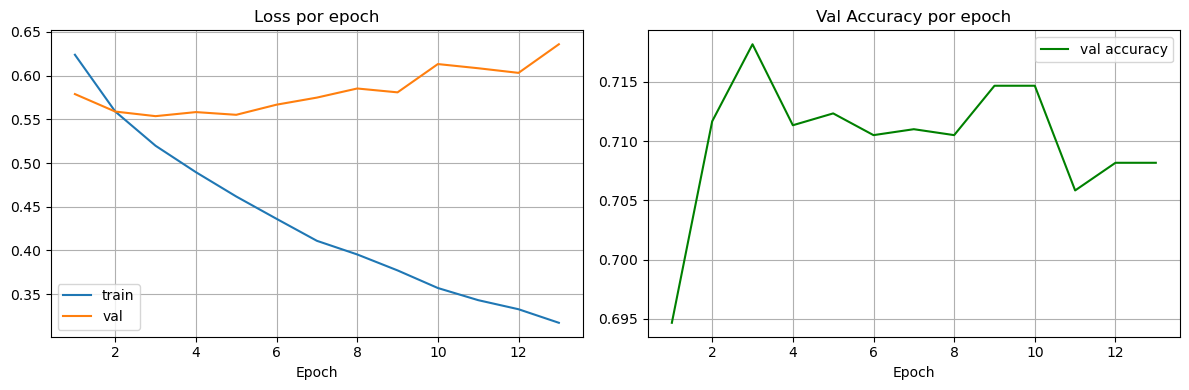

In [5]:
historia = train_mlp()